# Fraud Shield - Baseline Supervised Models

Trains and evaluates the three supervised baselines -- Logistic Regression,
Random Forest, and XGBoost -- using the engineered features from
`02_feature_engineering.ipynb`. These become the supervised branch that
feeds the hybrid ensemble in `05_hybrid_ensemble.ipynb`.

**Inputs:** `data/processed/train_features.parquet`, `data/processed/test_features.parquet`
**Outputs:** trained models saved to `data/processed/models/`, validation metrics


In [1]:
import sys
sys.path.append('..')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
import shap

from src.models.supervised import (
    train_logistic_regression,
    train_random_forest,
    train_xgboost,
)
from src.models.evaluate import compute_metrics, print_report, explain_model

MODELS_DIR = Path('../data/processed/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)


c:\Users\shami\anaconda3\envs\r_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load engineered features


In [2]:
train_df = pd.read_parquet('../data/processed/train_features.parquet')
test_df = pd.read_parquet('../data/processed/test_features.parquet')

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head()


Train shape: (1296675, 26)
Test shape:  (555719, 26)


,transaction_id,event_time,cc_num,amt,city_pop,geo_distance_km,txn_velocity,amt_zscore,amt_category_zscore,category_entertainment,...,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_F,gender_M,is_fraud
0,98e3dcf98101146a577f85a34e58feec,1546346835,60416207185,7.27,1645,127.606239,1.0,-0.397556,-0.441058,0,...,0,1,0,0,0,0,0,1,0,0
1,498120fc45d277f7c88e3dba79c33865,1546418697,60416207185,52.94,1645,110.308921,1.0,-0.025143,-0.660587,0,...,0,0,0,0,0,0,0,1,0,0
2,95f514bb993151347c7acdf8505c3d62,1546418856,60416207185,82.08,1645,21.787261,2.0,0.212477,1.173647,0,...,0,0,0,0,0,0,0,1,0,0
3,4f0c1a14e0aa7eb56a490780ef9268c5,1546432694,60416207185,34.79,1645,87.204215,1.0,-0.173146,-0.466870,0,...,1,0,0,0,0,0,0,1,0,0
4,3b2ebd3af508afba959640893e1e82bc,1546434646,60416207185,27.18,1645,74.212965,2.0,-0.235201,-0.638648,0,...,0,0,0,0,0,0,0,1,0,0


## 2. Split features/target

`transaction_id`, `event_time`, and `cc_num` are identifiers, not model
inputs -- keep them aside for traceability but drop them from `X`.

One-hot columns are explicitly cast to `int` here (rather than relying on
`pd.get_dummies(dtype=int)` upstream) as a defensive check -- newer XGBoost
versions silently treat `bool`-dtype columns as categorical, which breaks
SHAP's TreeExplainer later in this notebook. This has to happen *before*
the train/val split and model training, not after -- casting `X` post-hoc
doesn't change a model that's already been fit on the uncast columns.


In [3]:
id_cols = ['transaction_id', 'event_time', 'cc_num']
target_col = 'is_fraud'
feature_cols = [c for c in train_df.columns if c not in id_cols + [target_col]]

X = train_df[feature_cols].copy()

bool_cols = X.select_dtypes(include='bool').columns
if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

y = train_df[target_col]

print(f'{len(feature_cols)} features:')
print(feature_cols)


22 features:
['amt', 'city_pop', 'geo_distance_km', 'txn_velocity', 'amt_zscore', 'amt_category_zscore', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'gender_F', 'gender_M']


## 3. Train / validation split

`fraudTest.csv` is the true held-out test set (used only at the very end).
Here we carve a validation split out of the training data for model
selection and comparison, stratified on `is_fraud` to preserve the fraud rate
in both splits.


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape}, fraud rate {y_train.mean()*100:.4f}%')
print(f'Val:   {X_val.shape}, fraud rate {y_val.mean()*100:.4f}%')


Train: (1037340, 22), fraud rate 0.5789%
Val:   (259335, 22), fraud rate 0.5788%


## 4. Class imbalance handling

`train_logistic_regression` and `train_random_forest` already use
`class_weight='balanced'` by default. XGBoost needs an explicit
`scale_pos_weight` (ratio of negative to positive class counts).


In [5]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f'Negative: {neg}, Positive: {pos}, scale_pos_weight: {scale_pos_weight:.2f}')


Negative: 1031335, Positive: 6005, scale_pos_weight: 171.75


## 5. Train Logistic Regression


In [6]:
logreg = train_logistic_regression(X_train, y_train)

logreg_pred = logreg.predict(X_val)
logreg_proba = logreg.predict_proba(X_val)[:, 1]

logreg_metrics = compute_metrics(y_val, logreg_pred, logreg_proba)
print(logreg_metrics)
print_report(y_val, logreg_pred)


c:\Users\shami\anaconda3\envs\r_env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'precision': 0.05968402574605032, 'recall': 0.8154563624250499, 'f1': 0.11122722522604389, 'auc_roc': 0.9318424628002162}
              precision    recall  f1-score   support

       legit       1.00      0.93      0.96    257834
       fraud       0.06      0.82      0.11      1501

    accuracy                           0.92    259335
   macro avg       0.53      0.87      0.54    259335
weighted avg       0.99      0.92      0.96    259335



## 6. Train Random Forest


In [7]:
rf = train_random_forest(X_train, y_train)

rf_pred = rf.predict(X_val)
rf_proba = rf.predict_proba(X_val)[:, 1]

rf_metrics = compute_metrics(y_val, rf_pred, rf_proba)
print(rf_metrics)
print_report(y_val, rf_pred)


{'precision': 0.7538167938931297, 'recall': 0.7894736842105263, 'f1': 0.7712333224861698, 'auc_roc': 0.9883183299634963}
              precision    recall  f1-score   support

       legit       1.00      1.00      1.00    257834
       fraud       0.75      0.79      0.77      1501

    accuracy                           1.00    259335
   macro avg       0.88      0.89      0.88    259335
weighted avg       1.00      1.00      1.00    259335



## 7. Train XGBoost

`scale_pos_weight` pushes predicted probabilities upward across the board,
so the default 0.5 decision threshold badly under-performs here (high
recall, very low precision). The threshold is tuned via the
precision-recall curve to the F1-maximizing point instead -- this is still
the same trained model, just evaluated at a properly calibrated cutoff
rather than an arbitrary default.


In [8]:
xgb_model = train_xgboost(X_train, y_train, scale_pos_weight=scale_pos_weight)
xgb_proba = xgb_model.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, xgb_proba)

# F1 at each threshold (skip the last point, precision_recall_curve returns
# one more precision/recall pair than thresholds)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = f1_scores.argmax()
xgb_threshold = thresholds[best_idx]

xgb_pred = (xgb_proba >= xgb_threshold).astype(int)
xgb_metrics = compute_metrics(y_val, xgb_pred, xgb_proba)

print(f'Tuned decision threshold: {xgb_threshold:.4f}')
print(xgb_metrics)
print_report(y_val, xgb_pred)


Tuned decision threshold: 0.9867
{'precision': 0.7924137931034483, 'recall': 0.765489673550966, 'f1': 0.7787190782785497, 'auc_roc': 0.9965375932478069}
              precision    recall  f1-score   support

       legit       1.00      1.00      1.00    257834
       fraud       0.79      0.77      0.78      1501

    accuracy                           1.00    259335
   macro avg       0.90      0.88      0.89    259335
weighted avg       1.00      1.00      1.00    259335



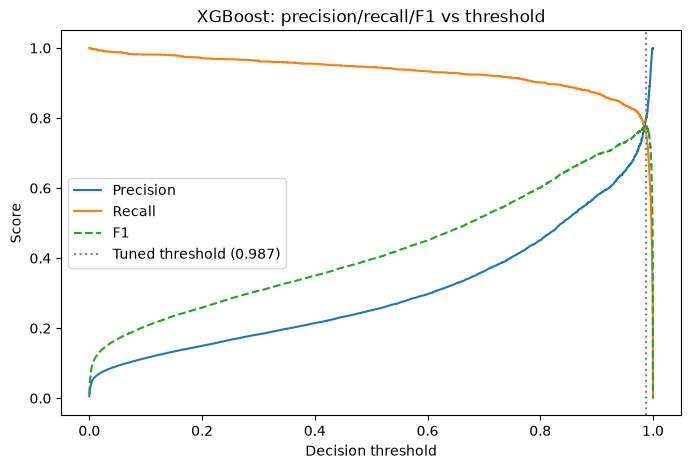

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions[:-1], label='Precision')
ax.plot(thresholds, recalls[:-1], label='Recall')
ax.plot(thresholds, f1_scores, label='F1', linestyle='--')
ax.axvline(xgb_threshold, color='gray', linestyle=':', label=f'Tuned threshold ({xgb_threshold:.3f})')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('XGBoost: precision/recall/F1 vs threshold')
ax.legend()
plt.show()


## 8. Compare models


In [10]:
results = pd.DataFrame({
    'Logistic Regression': logreg_metrics,
    'Random Forest': rf_metrics,
    'XGBoost (tuned threshold)': xgb_metrics,
}).T

results = results.sort_values('f1', ascending=False)
results


,precision,recall,f1,auc_roc
XGBoost (tuned threshold),0.792414,0.765490,0.778719,0.996538
Random Forest,0.753817,0.789474,0.771233,0.988318
Logistic Regression,0.059684,0.815456,0.111227,0.931842


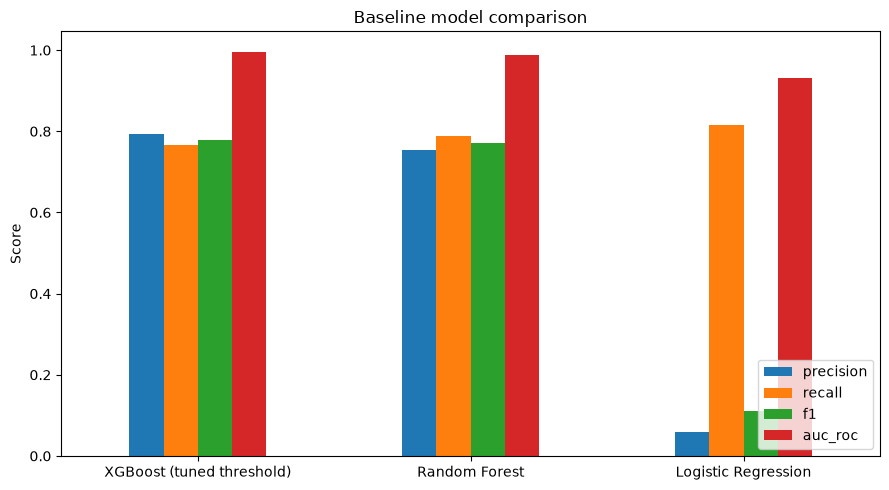

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
results[['precision', 'recall', 'f1', 'auc_roc']].plot(kind='bar', ax=ax)
ax.set_title('Baseline model comparison')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Feature importance / interpretability (XGBoost)

XGBoost typically performs best on tabular fraud data and pairs cleanly
with SHAP's TreeExplainer -- this doubles as the interpretability
deliverable the rubric calls for.


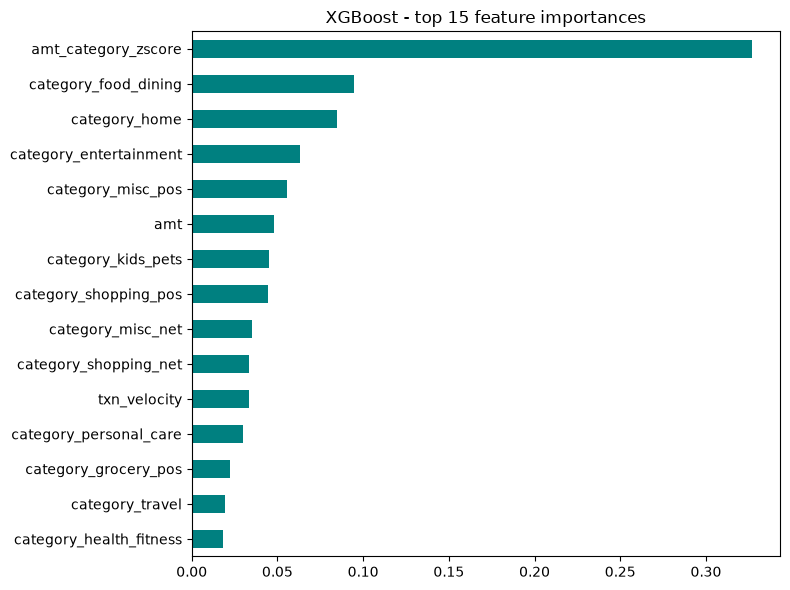

In [12]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='teal')
ax.invert_yaxis()
ax.set_title('XGBoost - top 15 feature importances')
plt.tight_layout()
plt.show()


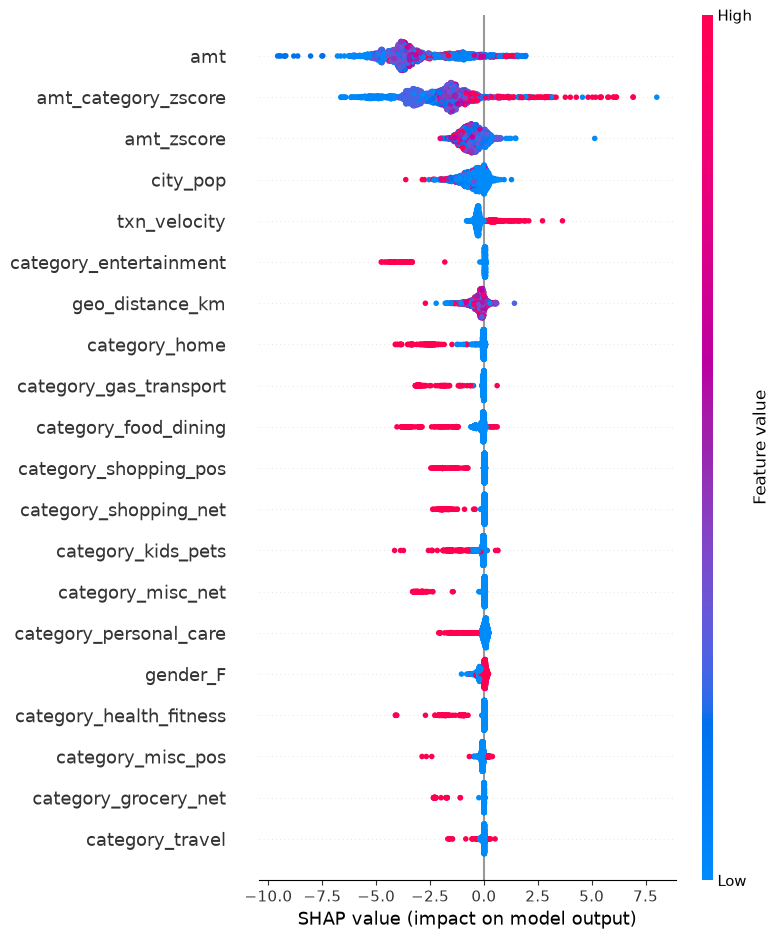

In [13]:
# SHAP can be slow on the full validation set -- sample for a readable summary plot.
# feature_perturbation='tree_path_dependent' avoids the categorical-split check that
# otherwise raises NotImplementedError against some XGBoost/SHAP version combinations.
X_val_sample = X_val.sample(n=min(2000, len(X_val)), random_state=42).astype(np.float64)
shap_values = explain_model(xgb_model, X_val_sample)

shap.summary_plot(shap_values, X_val_sample, show=True)


## 10. Save trained models

Saved under `data/processed/models/` (gitignored, same as the rest of
`data/`) so they're available to `05_hybrid_ensemble.ipynb` without
retraining.


In [14]:
joblib.dump(logreg, MODELS_DIR / 'logreg.joblib')
joblib.dump(rf, MODELS_DIR / 'random_forest.joblib')
joblib.dump(xgb_model, MODELS_DIR / 'xgboost.joblib')

# Also persist validation predictions -- reused as meta-features when building
# the hybrid ensemble, without needing to retrain here
val_predictions = pd.DataFrame({
    'is_fraud': y_val.values,
    'logreg_proba': logreg_proba,
    'rf_proba': rf_proba,
    'xgb_proba': xgb_proba,
})
val_predictions.to_parquet(MODELS_DIR / 'baseline_val_predictions.parquet', index=False)

print('Saved models and validation predictions to', MODELS_DIR)


Saved models and validation predictions to ..\data\processed\models


## 11. Next steps

- Compare against `04_deep_learning_models.ipynb` (FNN / LSTM branch)
- Feed `baseline_val_predictions.parquet` + the deep learning branch's
  validation probabilities into `05_hybrid_ensemble.ipynb`
- Note any weak spots here (e.g. recall on the fraud class) to target
  specifically when tuning the deep learning models
